<a href="https://colab.research.google.com/github/nightshadeX16/My-Colab-ML-Projects/blob/main/CIFAR_10_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
import pickle

# Unpickle function
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Define the path where files are located

data_dir = '/content/'

# Lists to hold the combined data
x_train_raw = []
y_train_raw = []

# Loop through data_batch_1 to data_batch_5
for i in range(1, 6):
    file_name = os.path.join(data_dir, f'data_batch_{i}')

    print(f"Loading {file_name}...")
    batch_data = unpickle(file_name)

    # Extract data (image pixels) and labels (categories)
    x_train_raw.append(batch_data[b'data'])
    y_train_raw.extend(batch_data[b'labels'])

# 5. Concatenate the lists into numpy arrays
# x_train will handle the image data
x_train = np.vstack(x_train_raw)
# y_train will handle the labels
y_train = np.array(y_train_raw)

print("-" * 30)
print(f"Total Training Images: {x_train.shape}")
print(f"Total Training Labels: {y_train.shape}")

Loading /content/data_batch_1...
Loading /content/data_batch_2...
Loading /content/data_batch_3...
Loading /content/data_batch_4...
Loading /content/data_batch_5...
------------------------------
Total Training Images: (50000, 3072)
Total Training Labels: (50000,)


In [ ]:
# Load the meta file
meta_file = os.path.join(data_dir, 'batches.meta')
meta_data = unpickle(meta_file)

# Extract the list of label names
# The key is in bytes, and the names inside are also in bytes
label_names = [x.decode('utf-8') for x in meta_data[b'label_names']]

# Display the mapping
print("Label Mapping:")
print("-" * 20)
for index, name in enumerate(label_names):
    print(f"Label {index}: {name}")

Label Mapping:
--------------------
Label 0: airplane
Label 1: automobile
Label 2: bird
Label 3: cat
Label 4: deer
Label 5: dog
Label 6: frog
Label 7: horse
Label 8: ship
Label 9: truck


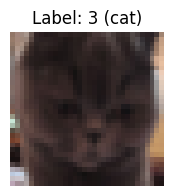

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 1. Pick a random index from 0 to 49999
index = random.randint(0, len(x_train) - 1)

# 2. Get the image data and label
img_flat = x_train[index] # Shape is likely (3072,)
label_idx = y_train[index]

# 3. Reshape the image for Matplotlib
# The dataset format is (Channels, Height, Width) -> (3, 32, 32)
# But Matplotlib wants (Height, Width, Channels) -> (32, 32, 3)
img_reshaped = img_flat.reshape(3, 32, 32).transpose(1, 2, 0)

# 4. Get the human-readable name
label_text = label_names[label_idx]

# 5. Display
plt.figure(figsize=(2, 2))
plt.imshow(img_reshaped)
plt.title(f"Label: {label_idx} ({label_text})")
plt.axis('off') # Hide the axis numbers for a cleaner look
plt.show()

In [ ]:
import os
import numpy as np

# Ensure your data directory is set correctly
data_dir = '/content'

# Load the test_batch file
test_file = os.path.join(data_dir, 'test_batch')

# Use your unpickle function to load it
# (Assuming 'unpickle' is already defined in your session from previous steps)
test_data = unpickle(test_file)

# Extract the data and labels
x_test = test_data[b'data']
y_test = np.array(test_data[b'labels'])

print("Test data loaded successfully!")
print(f"x_test shape: {x_test.shape}")

Test data loaded successfully!
x_test shape: (10000, 3072)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Reshape data to (Samples, Height, Width, Channels)
# Previous x_train was (50000, 3072). We reshape to (50000, 32, 32, 3)
x_train_processed = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test_processed = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# 2. Normalize pixel values to be between 0 and 1
x_train_processed = x_train_processed.astype('float32') / 255.0
x_test_processed = x_test_processed.astype('float32') / 255.0

# 3. One-hot encode the labels (e.g., 6 becomes [0,0,0,0,0,0,1,0,0,0])
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# 4. Data Augmentation Setup
datagen = ImageDataGenerator(
    rotation_range=15,      # Rotate images randomly by 15 degrees
    width_shift_range=0.1,  # Shift horizontally
    height_shift_range=0.1, # Shift vertically
    horizontal_flip=True,   # Flip images horizontally
    zoom_range=0.1          # Zoom in randomly
)
datagen.fit(x_train_processed)

print("Data Preprocessing Complete.")
print(f"Training shape: {x_train_processed.shape}")

Data Preprocessing Complete.
Training shape: (50000, 32, 32, 3)


In [ ]:
def build_model():
    model = models.Sequential()

    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 3
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))

    # Flatten and Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax')) # Output layer

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_model()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train for 50 epochs as requested
epochs = 50
batch_size = 64

history = cnn_model.fit(
    datagen.flow(x_train_processed, y_train_cat, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test_processed, y_test_cat),
    steps_per_epoch=len(x_train_processed) // batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 140s 176ms/step - accuracy: 0.3390 - loss: 1.7965 - val_accuracy: 0.5382 - val_loss: 1.2732
Epoch 2/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 1:22 106ms/step - accuracy: 0.4531 - loss: 1.5289

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4531 - loss: 1.5289 - val_accuracy: 0.5516 - val_loss: 1.2435
Epoch 3/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 135s 173ms/step - accuracy: 0.5321 - loss: 1.3050 - val_accuracy: 0.6111 - val_loss: 1.1093
Epoch 4/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6250 - loss: 0.9652 - val_accuracy: 0.6112 - val_loss: 1.1037
Epoch 5/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 136s 175ms/step - accuracy: 0.5886 - loss: 1.1588 - val_accuracy: 0.6327 - val_loss: 1.0272
Epoch 6/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6562 - loss: 1.1448 - val_accuracy: 0.6356 - val_loss: 1.0267
Epoch 7/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 134s 172ms/step - accuracy: 0.6317 - loss: 1.0454 - val_accuracy: 0.6745 - val_loss: 0.9346
Epoch 8/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6250 - loss: 1.1135 - val_accuracy: 0.6737 - val_loss: 0.9440
Epoch 9/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 135s 173ms/step - accuracy: 0.6564 - loss: 0.9742 - val_a

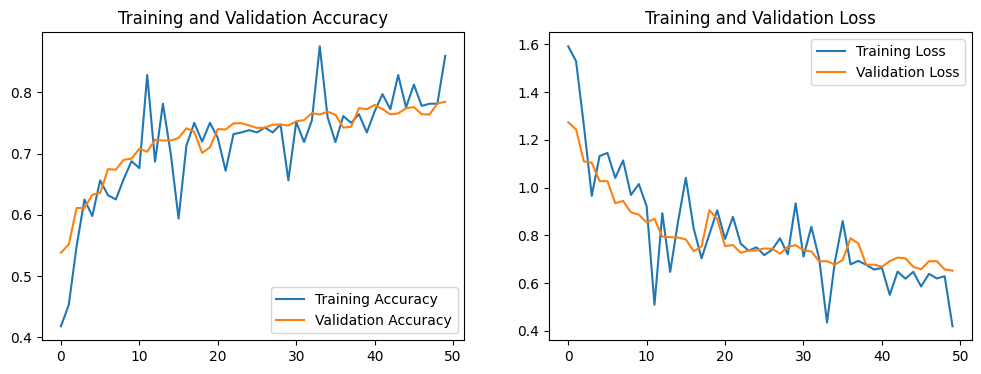

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.81      0.81      1000
  automobile       0.87      0.91      0.89      1000
        bird       0.85      0.56      0.67      1000
         cat       0.67      0.59      0.63      1000
        deer       0.81      0.68      0.74      1000
         dog       0.64      0.78      0.70      1000
        frog       0.76      0.88      0.82      1000
       horse       0.80      0.86      0.83      1000
        ship       0.92      0.86      0.89      1000
       truck       0.77      0.92      0.84      1000

    accuracy                           0.78     10000
   macro avg       0.79      0.78      0.78     10000
weighted avg       0.79      0.78      0.78     10000



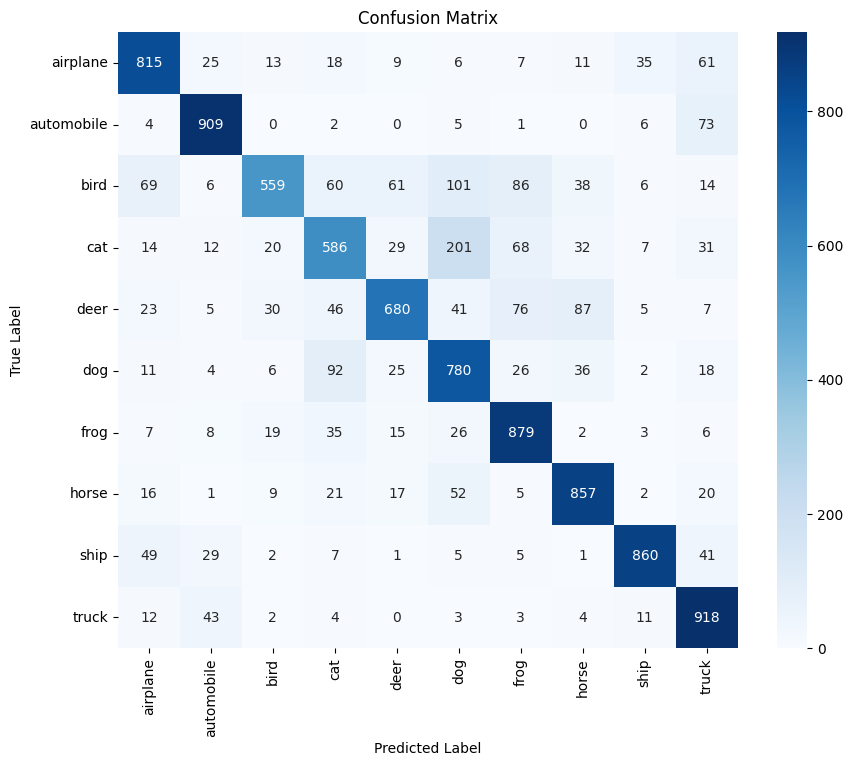

In [ ]:
# 1. Plot Accuracy and Loss Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# 2. Confusion Matrix and Metrics
y_pred = cnn_model.predict(x_test_processed)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test  # Original integer labels

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_names))

conf_mat = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


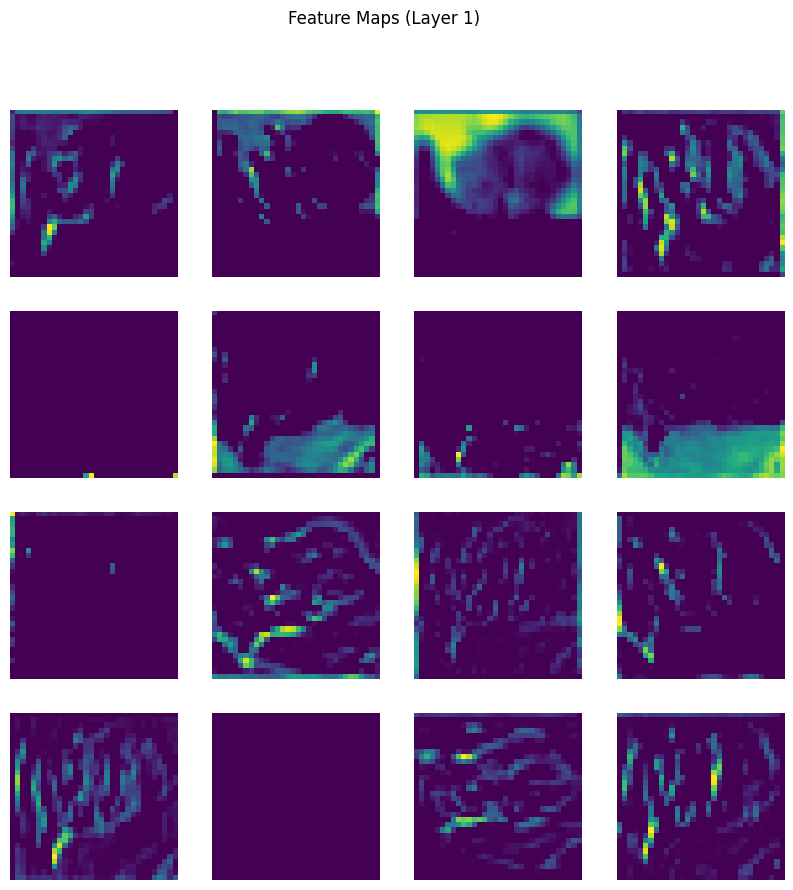

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models

# --- Step 5: Visualization (Feature Maps) ---

# CRITICAL FIX: Force the model to run on dummy data.
# This guarantees 'cnn_model.input' is fully defined.
dummy_data = np.zeros((1, 32, 32, 3), dtype=np.float32)
_ = cnn_model(dummy_data)

# 1. Select a random image from the test set to visualize
img_to_visualize = x_test_processed[0]
img_to_visualize = np.expand_dims(img_to_visualize, axis=0)

# 2. Create a new model that outputs the feature maps
# We search for layers with 'conv2d' in their name
layer_outputs = [layer.output for layer in cnn_model.layers if 'conv2d' in layer.name]

if not layer_outputs:
    print("Error: No Conv2D layers found. Please check your model architecture.")
else:
    # We use cnn_model.inputs (plural) which is often safer in newer Keras versions
    activation_model = models.Model(inputs=cnn_model.inputs, outputs=layer_outputs)

    # 3. Get the feature maps (activations) for the selected image
    activations = activation_model.predict(img_to_visualize)

    # Extract the first layer's activations
    # (If multiple conv layers, activations is a list; take the first one)
    if isinstance(activations, list):
        first_layer_activation = activations[0]
    else:
        first_layer_activation = activations

    # 4. Plot the first 16 feature maps (filters) from the first layer
    plt.figure(figsize=(10, 10))
    for i in range(16):
        if i < first_layer_activation.shape[-1]: # Ensure we don't exceed available filters
            plt.subplot(4, 4, i + 1)
            plt.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
            plt.axis('off')

    plt.suptitle("Feature Maps (Layer 1)")
    plt.show()